In [2]:
# Cell 1: Download dataset (run once)
import kagglehub

# downloads dataset and returns a local folder path
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print("Path to dataset files:", path)


Path to dataset files: /Users/anshparmar/.cache/kagglehub/datasets/mlg-ulb/creditcardfraud/versions/3


In [3]:
# Cell 2: Quick verification of files
import os
print("Files in downloaded folder:")
for f in os.listdir(path):
    print(" -", f)


Files in downloaded folder:
 - creditcard.csv


In [6]:
# Cell 3: Set csv_path (point to downloaded CSV or a local CSV)
import os

folder = path
csv_path = os.path.join(folder, "creditcard.csv")

# If you uploaded a CSV to /mnt/data and want to use it instead, set local_csv_path
local_csv_path = '/mnt/data/your_transactions.csv'  # replace if you uploaded a CSV locally


# Use local CSV if present and no kaggle file found
if os.path.exists(local_csv_path) and not os.path.exists(csv_path):
    csv_path = local_csv_path

print('Using CSV path:', csv_path)


Using CSV path: /Users/anshparmar/.cache/kagglehub/datasets/mlg-ulb/creditcardfraud/versions/3/creditcard.csv


In [12]:
#Cell 4: Import libraries
import os, glob, math, joblib, json, datetime
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, confusion_matrix, precision_recall_fscore_support, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers, backend as K

import xgboost as xgb
import shap

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [13]:
# Cell 5: Load dataset and quick EDA
if not os.path.exists(csv_path):
    raise FileNotFoundError(f"CSV not found at {csv_path}. Make sure Cell 1 ran and path is correct.")

print("Loading dataset from:", csv_path)
df = pd.read_csv(csv_path)
print("Loaded shape:", df.shape)
display(df.head())
print(df.info())

# Save metadata for reproducibility
meta = {
    'kagglehub_path': path,
    'local_reference_notebook': local_reference_notebook,
    'loaded_at': datetime.datetime.utcnow().isoformat() + 'Z'
}
with open('metadata.json','w') as f:
    json.dump(meta,f)
print('Saved metadata.json')


Loading dataset from: /Users/anshparmar/.cache/kagglehub/datasets/mlg-ulb/creditcardfraud/versions/3/creditcard.csv
Loaded shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [14]:
# Cell 6: CONFIG
CONFIG = {
    'use_robust_scaler': True,     # RobustScaler vs StandardScaler
    'use_pca': False,              # Apply PCA if True
    'pca_n_components': 20,
    'use_vae': False,              # set True to run VAE instead of dense AE
    'autoencoder_epochs': 100,
    'autoencoder_batch_size': 256,
    'xgb_use_cv': True,
    'xgb_n_splits': 5,
    'save_artifacts': True,
}
print('CONFIG:', CONFIG)


CONFIG: {'use_robust_scaler': True, 'use_pca': False, 'pca_n_components': 20, 'use_vae': False, 'autoencoder_epochs': 100, 'autoencoder_batch_size': 256, 'xgb_use_cv': True, 'xgb_n_splits': 5, 'save_artifacts': True}


In [15]:
# Cell 7: Preprocessing
# Detect label
label_col = None
for c in ['Class','isFraud','fraud','label','is_fraud']:
    if c in df.columns:
        label_col = c
        break

if label_col:
    print('Detected label column:', label_col)
    y = df[label_col].astype(int).copy()
    X_df = df.drop(columns=[label_col])
else:
    print('No label found; proceeding unsupervised')
    y = None
    X_df = df.copy()

# Time feature engineering
if 'Time' in X_df.columns:
    try:
        X_df['hour'] = (X_df['Time'] // 3600) % 24
    except Exception:
        pass
    X_df = X_df.drop(columns=['Time'])

# One-hot encode low-cardinality categoricals
cat_cols = [c for c in X_df.columns if X_df[c].dtype == 'object' or X_df[c].nunique() < 50]
cat_cols = [c for c in cat_cols if X_df[c].nunique() < 200]
if len(cat_cols) > 0:
    print('One-hot encoding:', cat_cols)
    X_df = pd.get_dummies(X_df, columns=cat_cols, drop_first=True)

# Fill na and clip outliers (1st-99th percentile)
num_cols = X_df.select_dtypes(include=[np.number]).columns.tolist()
for c in num_cols:
    X_df[c] = X_df[c].fillna(X_df[c].median())
for c in num_cols:
    low, high = X_df[c].quantile(0.01), X_df[c].quantile(0.99)
    X_df[c] = X_df[c].clip(lower=low, upper=high)

# Scale
if CONFIG['use_robust_scaler']:
    scaler = RobustScaler()
else:
    scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_df.values)
print('Scaled shape:', X_scaled.shape)

# Optional PCA
if CONFIG['use_pca']:
    pca = PCA(n_components=CONFIG['pca_n_components'], random_state=SEED)
    X_scaled = pca.fit_transform(X_scaled)
    print('PCA applied, new shape:', X_scaled.shape)

if CONFIG['save_artifacts']:
    joblib.dump(scaler, 'scaler.joblib')
    if CONFIG['use_pca']:
        joblib.dump(pca, 'pca.joblib')
    print('Saved scaler and PCA (if used)')

df_orig = df.copy()


Detected label column: Class
One-hot encoding: ['hour']
Scaled shape: (284807, 52)
Saved scaler and PCA (if used)


In [16]:
# Cell 8: Train/val/test preparation for AE
if y is not None:
    normal_idx = np.where(y == 0)[0]
    X_train_full = X_scaled[normal_idx]
    X_train, X_val = train_test_split(X_train_full, test_size=0.2, random_state=SEED)
    X_test = X_scaled
    y_test = y.values
    print('Training autoencoder on normals only. #normals:', X_train_full.shape[0])
else:
    X_train, X_val, X_test = train_test_split(X_scaled, X_scaled, test_size=0.2, random_state=SEED)
    y_test = None


Training autoencoder on normals only. #normals: 284315


In [17]:
# Cell 9: Dense Autoencoder builder
from tensorflow.keras import regularizers

def build_dense_autoencoder(input_dim, encoding_dim):
    inp = layers.Input(shape=(input_dim,))
    x = layers.Dense(max(256, input_dim), activation='relu')(inp)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(64, activation='relu')(x)
    encoded = layers.Dense(encoding_dim, activation='relu', name='bottleneck')(x)
    x = layers.Dense(64, activation='relu')(encoded)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(max(256, input_dim), activation='relu')(x)
    out = layers.Dense(input_dim, activation='linear')(x)
    model = models.Model(inputs=inp, outputs=out)
    model.compile(optimizer='adam', loss='mse')
    return model


In [18]:
# Cell 10: Variational Autoencoder builder (optional)
from tensorflow.keras import backend as K

def build_vae(input_dim, latent_dim=16):
    inputs = layers.Input(shape=(input_dim,))
    x = layers.Dense(128, activation='relu')(inputs)
    x = layers.Dense(64, activation='relu')(x)
    z_mean = layers.Dense(latent_dim, name='z_mean')(x)
    z_log_var = layers.Dense(latent_dim, name='z_log_var')(x)

    def sampling(args):
        z_mean, z_log_var = args
        epsilon = K.random_normal(shape=(K.shape(z_mean)[0], latent_dim), mean=0., stddev=1.)
        return z_mean + K.exp(0.5 * z_log_var) * epsilon

    z = layers.Lambda(sampling, output_shape=(latent_dim,), name='z')([z_mean, z_log_var])

    decoder_h1 = layers.Dense(64, activation='relu')
    decoder_h2 = layers.Dense(128, activation='relu')
    decoder_out = layers.Dense(input_dim, activation='linear')

    h_decoded = decoder_h1(z)
    h_decoded = decoder_h2(h_decoded)
    x_decoded_mean = decoder_out(h_decoded)

    vae = models.Model(inputs, x_decoded_mean)

    recon_loss = tf.reduce_mean(tf.square(inputs - x_decoded_mean))
    kl_loss = -0.5 * tf.reduce_mean(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
    vae_loss = recon_loss + kl_loss
    vae.add_loss(vae_loss)
    vae.compile(optimizer='adam')
    return vae


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 52)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        13,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 13)             │           845 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 52)             │        13,364 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,169 (434.25 KB)

 Trainable params: 111,169 (434.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
889/889 - 4s - 5ms/step - loss: 0.1259 - val_loss: 0.0622
Epoch 2/100
889/889 - 3s - 3ms/step - loss: 0.0541 - val_loss: 0.0498
Epoch 3/100
889/889 - 3s - 3ms/step - loss: 0.0461 - val_loss: 0.0440
Epoch 4/100
889/889 - 3s - 3ms/step - loss: 0.0425 - val_loss: 0.0414
Epoch 5/100
889/889 - 3s - 3ms/step - loss: 0.0402 - val_loss: 0.0395
Epoch 6/100
889/889 - 3s - 3ms/step - loss: 0.0386 - val_loss: 0.0382
Epoch 7/100
889/889 - 3s - 3ms/step - loss: 0.0373 - val_loss: 0.0368
Epoch 8/100
889/889 - 3s - 3ms/step - loss: 0.0361 - val_loss: 0.0359
Epoch 9/100
889/889 - 3s - 3ms/step - loss: 0.0352 - val_loss: 0.0353
Epoch 10/100
889/889 - 2s - 3ms/step - loss: 0.0344 - val_loss: 0.0344
Epoch 11/100
889/889 - 2s - 3ms/step - loss: 0.0337 - val_loss: 0.0339
Epoch 12/100
889/889 - 3s - 3ms/step - loss: 0.0330 - val_loss: 0.0339
Epoch 13/100
889/889 - 3s - 3ms/step - loss: 0.0323 - val_loss: 0.0328
Epoch 14/100
889/889 - 3s - 3ms/step - loss: 0.0317 - val_loss: 0.0325
Epoch 15/100
88

Saved autoencoder_model.h5


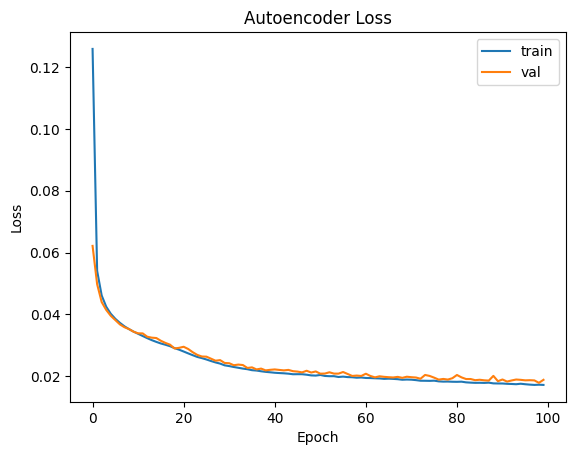

In [19]:
# Cell 11: Train AE
input_dim = X_train.shape[1]
encoding_dim = max(8, input_dim // 4)

if CONFIG['use_vae']:
    model_ae = build_vae(input_dim, latent_dim=encoding_dim)
else:
    model_ae = build_dense_autoencoder(input_dim, encoding_dim)

model_ae.summary()

es = callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
if CONFIG['use_vae']:
    history = model_ae.fit(X_train, epochs=CONFIG['autoencoder_epochs'], batch_size=CONFIG['autoencoder_batch_size'], validation_data=(X_val, None), callbacks=[es], verbose=2)
else:
    history = model_ae.fit(X_train, X_train, epochs=CONFIG['autoencoder_epochs'], batch_size=CONFIG['autoencoder_batch_size'], validation_data=(X_val, X_val), callbacks=[es], verbose=2)

if CONFIG['save_artifacts']:
    model_ae.save('autoencoder_model.h5')
    print('Saved autoencoder_model.h5')

# Plot loss curve
plt.figure(); plt.plot(history.history.get('loss', []))
if 'val_loss' in history.history:
    plt.plot(history.history['val_loss'])
plt.title('Autoencoder Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(['train','val'] if 'val_loss' in history.history else ['train']); plt.show()


8901/8901 ━━━━━━━━━━━━━━━━━━━━ 3s 387us/step
Example MSE: [0.01703025 0.00338844 0.01178835 0.01060539 0.01520876]
Recon-only AUC: 0.9406
7108/7108 ━━━━━━━━━━━━━━━━━━━━ 3s 375us/step
Threshold (mean+3std): 0.08669556778056699
Recon-only detector -> precision: 0.07292035398230089 recall: 0.8373983739837398 f1: 0.13415825464018236


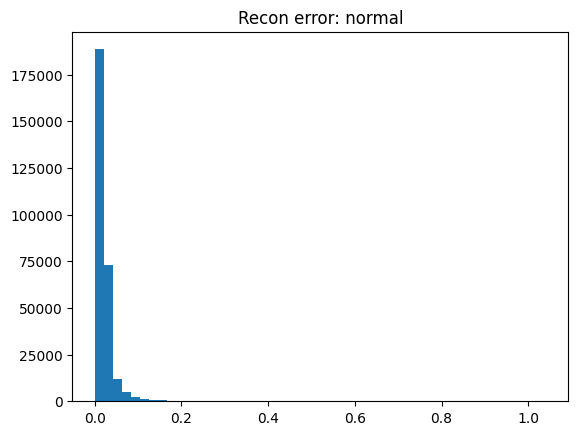

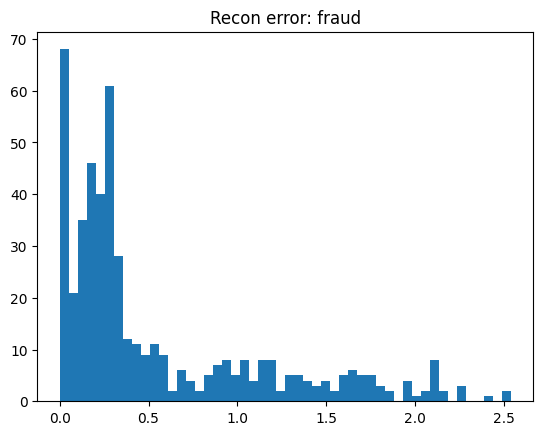

In [20]:
# Cell 12: Reconstruction error
X_test_pred = model_ae.predict(X_test)
mse = np.mean(np.square(X_test - X_test_pred), axis=1)
print('Example MSE:', mse[:5])

df_with_scores = df_orig.copy()
df_with_scores['recon_error'] = mse

if y_test is not None:
    auc_score = roc_auc_score(y_test, mse)
    print(f'Recon-only AUC: {auc_score:.4f}')
    train_pred = model_ae.predict(X_train)
    train_mse = np.mean(np.square(X_train - train_pred), axis=1)
    thr = train_mse.mean() + 3 * train_mse.std()
    print('Threshold (mean+3std):', thr)
    y_pred_re = (mse > thr).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_re, average='binary', zero_division=0)
    print('Recon-only detector -> precision:', precision, 'recall:', recall, 'f1:', f1)
    plt.figure(); plt.hist(mse[y_test==0], bins=50); plt.title('Recon error: normal'); plt.show()
    plt.figure(); plt.hist(mse[y_test==1], bins=50); plt.title('Recon error: fraud'); plt.show()


In [21]:
# Cell 13: Prepare features for XGBoost
X_for_xgb = np.hstack([X_scaled, mse.reshape(-1,1)])
feature_names = list(X_df.columns) + ['recon_error']
print('X_for_xgb shape:', X_for_xgb.shape)

if y_test is None:
    top_idx = np.argsort(mse)[-20:][::-1]
    print('Top anomalies (unsupervised):')
    display(df_with_scores.iloc[top_idx].head(20))
    raise SystemExit('No labels present — supervised XGBoost training skipped.')


X_for_xgb shape: (284807, 53)


In [26]:
# Cell 14 (fixed): XGBoost training (CV or single split), robust to different xgboost versions
from inspect import signature

EARLY_STOP = 20  # desired early stopping rounds

if CONFIG['xgb_use_cv']:
    skf = StratifiedKFold(n_splits=CONFIG['xgb_n_splits'], shuffle=True, random_state=SEED)
    aucs = []; models_cv = []; fold = 0
    for train_idx, val_idx in skf.split(X_for_xgb, y_test):
        fold += 1
        print('Fold', fold)
        Xtr, Xv = X_for_xgb[train_idx], X_for_xgb[val_idx]
        ytr, yv = y_test[train_idx], y_test[val_idx]
        clf = xgb.XGBClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            use_label_encoder=False,
            eval_metric='auc',
            random_state=SEED
        )
        pos = np.sum(ytr==1); neg = np.sum(ytr==0)
        if pos == 0:
            print("Warning: no positive samples in this fold's training set. Skipping this fold.")
            continue
        clf.set_params(scale_pos_weight = max(1, neg//(pos+1)))
        # Try to call fit with early_stopping_rounds; fall back if not supported
        try:
            # Some xgboost versions accept early_stopping_rounds in fit
            clf.fit(Xtr, ytr, eval_set=[(Xv,yv)], early_stopping_rounds=EARLY_STOP, verbose=False)
        except TypeError:
            # older/newer versions may not accept early_stopping_rounds here — fallback
            print("fit() rejected early_stopping_rounds, retrying without it (no early stopping)...")
            clf.fit(Xtr, ytr, eval_set=[(Xv,yv)], verbose=False)
        prob = clf.predict_proba(Xv)[:,1]
        auc_fold = roc_auc_score(yv, prob)
        print('Fold AUC:', auc_fold)
        aucs.append(auc_fold); models_cv.append(clf)
    if len(aucs) == 0:
        raise RuntimeError("No CV folds completed successfully (check your labels / stratification).")
    print('CV AUC mean:', np.mean(aucs), 'std:', np.std(aucs))
    best_idx = int(np.argmax(aucs)); best_clf = models_cv[best_idx]
else:
    X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
        X_for_xgb, y_test, test_size=0.2, stratify=y_test, random_state=SEED
    )
    best_clf = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        use_label_encoder=False,
        eval_metric='auc',
        random_state=SEED
    )
    pos = np.sum(y_train_xgb==1); neg = np.sum(y_train_xgb==0)
    if pos == 0:
        raise RuntimeError("No positive samples in training split — cannot train supervised classifier.")
    best_clf.set_params(scale_pos_weight = max(1, neg//(pos+1)))
    try:
        best_clf.fit(X_train_xgb, y_train_xgb, eval_set=[(X_test_xgb,y_test_xgb)], early_stopping_rounds=EARLY_STOP, verbose=False)
    except TypeError:
        print("fit() rejected early_stopping_rounds, retraining without early stopping...")
        best_clf.fit(X_train_xgb, y_train_xgb, eval_set=[(X_test_xgb,y_test_xgb)], verbose=False)

if CONFIG['save_artifacts']:
    joblib.dump(best_clf, 'xgb_best.joblib')
    print('Saved xgb_best.joblib')


Fold 1
fit() rejected early_stopping_rounds, retrying without it (no early stopping)...


/Users/anshparmar/Documents/JN/anaconda3/envs/nnlab/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [12:08:13] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold AUC: 0.9814588918927418
Fold 2
fit() rejected early_stopping_rounds, retrying without it (no early stopping)...


/Users/anshparmar/Documents/JN/anaconda3/envs/nnlab/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [12:08:15] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold AUC: 0.9741002519434891
Fold 3
fit() rejected early_stopping_rounds, retrying without it (no early stopping)...


...

Fold AUC: 0.9914109709444864
Fold 4
fit() rejected early_stopping_rounds, retrying without it (no early stopping)...


/Users/anshparmar/Documents/JN/anaconda3/envs/nnlab/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [12:08:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold AUC: 0.974666105824705
Fold 5
fit() rejected early_stopping_rounds, retrying without it (no early stopping)...


/Users/anshparmar/Documents/JN/anaconda3/envs/nnlab/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [12:08:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold AUC: 0.9894707544484828
CV AUC mean: 0.9822213950107811 std: 0.007219671578513958
Saved xgb_best.joblib


Test AUC: 0.9988705597602012
              precision    recall  f1-score   support

           0     0.9999    1.0000    1.0000     56864
           1     0.9895    0.9592    0.9741        98

    accuracy                         0.9999     56962
   macro avg     0.9947    0.9796    0.9870     56962
weighted avg     0.9999    0.9999    0.9999     56962



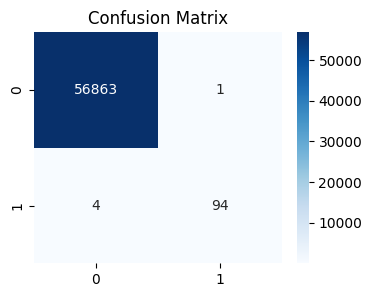

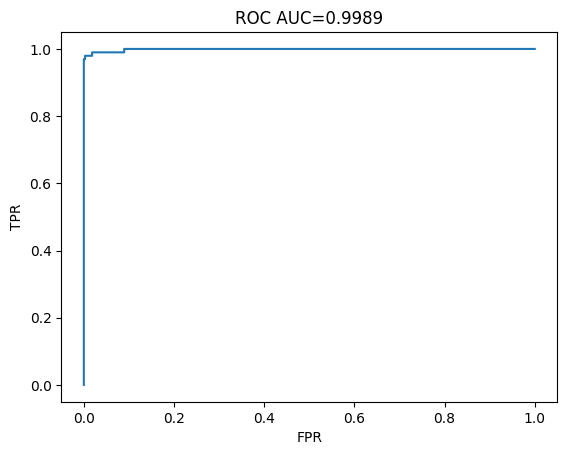

In [27]:
# Cell 15: Evaluate XGBoost
if CONFIG['xgb_use_cv']:
    X_train_x, X_holdout, y_train_x, y_holdout = train_test_split(X_for_xgb, y_test, test_size=0.2, stratify=y_test, random_state=SEED)
    y_prob = best_clf.predict_proba(X_holdout)[:,1]
    y_pred = (y_prob > 0.5).astype(int)
    test_auc = roc_auc_score(y_holdout, y_prob)
    target_true = y_holdout
else:
    y_prob = best_clf.predict_proba(X_test_xgb)[:,1]
    y_pred = (y_prob > 0.5).astype(int)
    test_auc = roc_auc_score(y_test_xgb, y_prob)
    target_true = y_test_xgb

print('Test AUC:', test_auc)
print(classification_report(target_true, y_pred, digits=4))
cm = confusion_matrix(target_true, y_pred)
plt.figure(figsize=(4,3)); sns.heatmap(cm, annot=True, fmt='d', cmap='Blues'); plt.title('Confusion Matrix'); plt.show()
fpr, tpr, _ = roc_curve(target_true, y_prob)
plt.figure(); plt.plot(fpr,tpr); plt.title(f'ROC AUC={test_auc:.4f}'); plt.xlabel('FPR'); plt.ylabel('TPR'); plt.show()


/var/folders/5w/8vqnph5d7js8bg3pztrj7s8h0000gn/T/ipykernel_2669/1553020883.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, pd.DataFrame(sample, columns=feature_names), show=True)


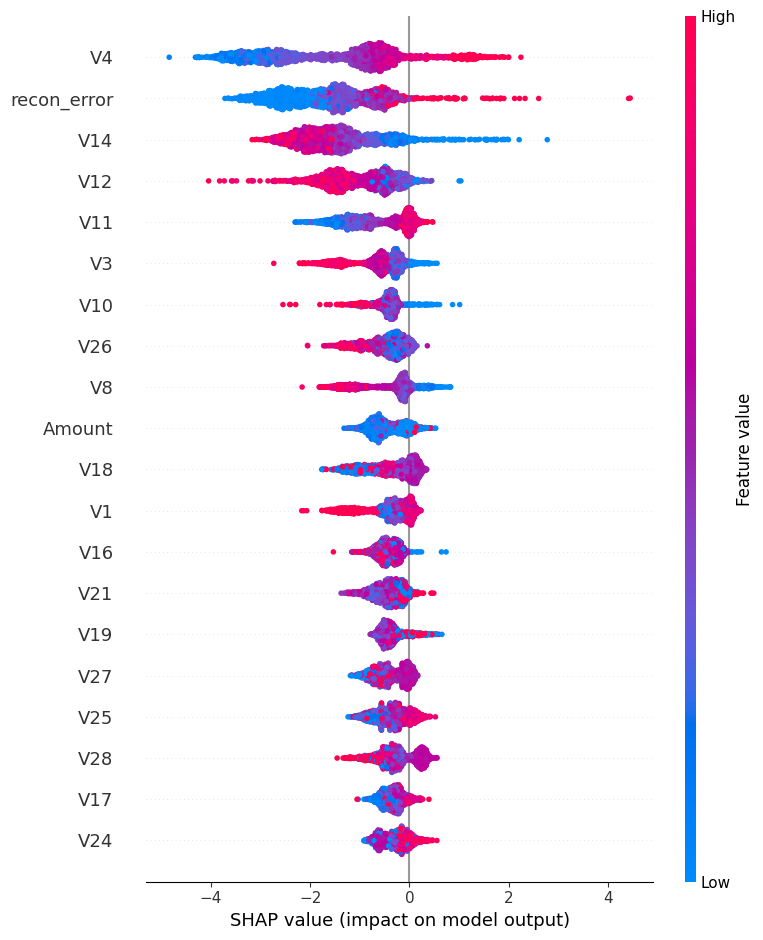

Saved shap_values_sample.csv


In [28]:
# Cell 16: SHAP explainability
explainer = shap.TreeExplainer(best_clf)
sample_idx = np.random.choice(X_for_xgb.shape[0], size=min(2000, X_for_xgb.shape[0]), replace=False)
sample = X_for_xgb[sample_idx]
shap_values = explainer.shap_values(sample)

# summary plot
shap.summary_plot(shap_values, pd.DataFrame(sample, columns=feature_names), show=True)

# save a sample of SHAP values
shap_df = pd.DataFrame(shap_values, columns=feature_names)
shap_df.to_csv('shap_values_sample.csv', index=False)
print('Saved shap_values_sample.csv')


,feature,gain
13,V14,5571.038086
51,recon_error,1510.857788
3,V4,708.003723
16,V17,370.132385
50,hour_23.0,348.228699
41,hour_14.0,343.938751
47,hour_20.0,300.551544
7,V8,287.070343
11,V12,263.166016
30,hour_2.0,236.409653


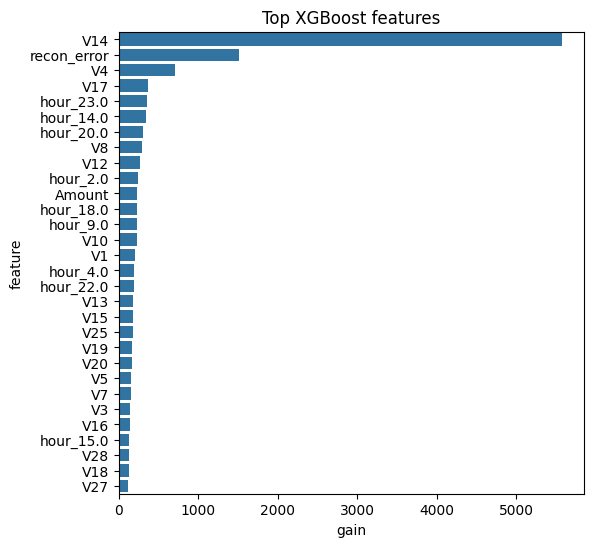

Recon_error feature index: 52


In [29]:
# Cell 17: Feature importance
booster = best_clf.get_booster() if hasattr(best_clf, 'get_booster') else None
if booster is not None:
    importance_dict = booster.get_score(importance_type='gain')
    imp_items = []
    for k,v in importance_dict.items():
        idx = int(k[1:])
        fname = feature_names[idx] if idx < len(feature_names) else f'f{idx}'
        imp_items.append((fname, v))
    imp_df = pd.DataFrame(imp_items, columns=['feature','gain']).sort_values('gain', ascending=False).head(30)
    display(imp_df)
    plt.figure(figsize=(6,6)); sns.barplot(x='gain', y='feature', data=imp_df); plt.title('Top XGBoost features'); plt.show()

if 'recon_error' in feature_names:
    print('Recon_error feature index:', feature_names.index('recon_error'))


In [30]:
# Cell 18: Save final outputs
# Full predictions (handle sklearn/xgboost differences)
if hasattr(best_clf, 'predict_proba'):
    full_probs = best_clf.predict_proba(X_for_xgb)
    if full_probs.ndim == 2:
        df_with_scores['xgb_prob'] = full_probs[:,1]
    else:
        df_with_scores['xgb_prob'] = full_probs
else:
    # fallback for any object
    df_with_scores['xgb_prob'] = best_clf.predict(X_for_xgb)

out_csv = 'transactions_with_scores_improved.csv'
df_with_scores.to_csv(out_csv, index=False)
print('Saved', out_csv)

artifacts = {
    'autoencoder_model': 'autoencoder_model.h5',
    'xgb_model': 'xgb_best.joblib',
    'scaler': 'scaler.joblib',
    'pca': 'pca.joblib' if CONFIG['use_pca'] else None,
    'shap_sample': 'shap_values_sample.csv',
    'scored_csv': out_csv,
    'metadata': 'metadata.json'
}
with open('artifacts.json','w') as f:
    json.dump(artifacts,f)
print('Saved artifacts.json')


Saved transactions_with_scores_improved.csv
Saved artifacts.json


In [31]:
# Cell 19: Short run summary
print('Run Summary:')
print(' - Kagglehub path:', meta['kagglehub_path'])
print(' - Autoencoder type:', 'VAE' if CONFIG['use_vae'] else 'Dense AE')
print(' - XGBoost CV used:', CONFIG['xgb_use_cv'])
print(' - Final test AUC:', float(test_auc))
print('Artifacts saved to artifacts.json')


Run Summary:
 - Kagglehub path: /Users/anshparmar/.cache/kagglehub/datasets/mlg-ulb/creditcardfraud/versions/3
 - Autoencoder type: Dense AE
 - XGBoost CV used: True
 - Final test AUC: 0.9988705597602012
Artifacts saved to artifacts.json
